# Cybersecurity Intrusion Detection — Machine Learning Model

## Loading the Data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("cybersecurity_intrusion_data_.csv")
print(df.shape)
df.head()

(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 1010.7 KB


In [3]:
df.isnull().sum()

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

In [4]:
df["encryption_used"] = df["encryption_used"].fillna("None")
df.isnull().sum().sum()   # should be 0 now

np.int64(0)

## Target

In [5]:
df["attack_detected"].value_counts()

attack_detected
0    5273
1    4264
Name: count, dtype: int64

## X and y

In [6]:
feature_cols = [c for c in df.columns if c not in ["session_id", "attack_detected"]]

X = df[feature_cols]
y = df["attack_detected"]

X = pd.get_dummies(X, columns=["protocol_type", "encryption_used", "browser_type"], drop_first=True)
X.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,encryption_used_None,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,599,4,492.983263,0.606818,1,0,True,False,True,False,True,False,False,False
1,472,3,1557.996461,0.301569,0,0,True,False,True,False,False,True,False,False
2,629,3,75.044262,0.739164,2,0,True,False,True,False,False,False,False,False
3,804,4,601.248835,0.123267,0,0,False,True,True,False,False,False,False,True
4,453,5,532.540888,0.054874,1,0,True,False,False,False,False,True,False,False


##  Data Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7629, 14)
(1908, 14)


## Model Training - RANDOM FOREST

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

##  Predictions

In [9]:
predictions = model.predict(X_test)

print("Predicted:", predictions[:20])
print("Actual:   ", y_test.values[:20])

Predicted: [1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0]
Actual:    [1 1 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0]


## Evaluation

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8857


## Features


In [11]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

failed_logins           0.282174
ip_reputation_score     0.223561
login_attempts          0.216204
session_duration        0.104786
network_packet_size     0.095976
browser_type_Unknown    0.027427
unusual_time_access     0.008172
encryption_used_DES     0.007653
encryption_used_None    0.006594
browser_type_Edge       0.006359
browser_type_Firefox    0.006249
protocol_type_TCP       0.006227
protocol_type_UDP       0.005323
browser_type_Safari     0.003295
dtype: float64

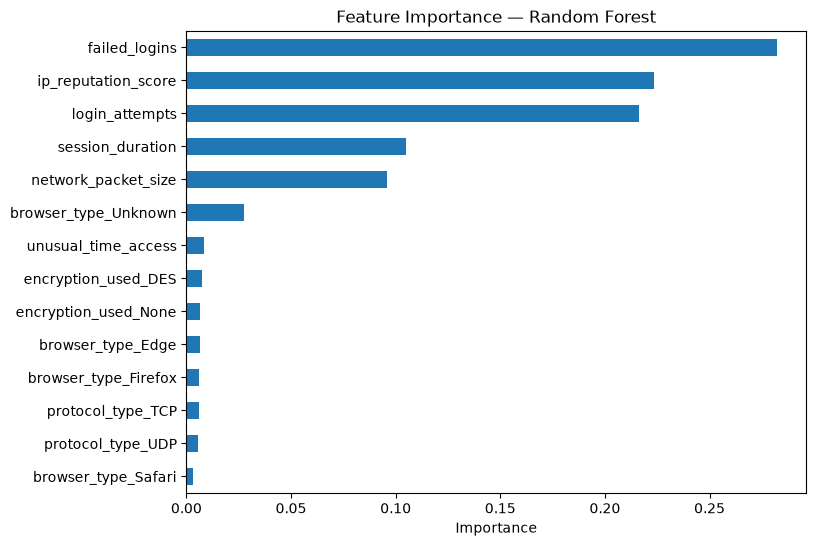

In [14]:
import matplotlib.pyplot as plt
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)
importances.sort_values(ascending=False).plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [15]:
i = 0
sample = X_test.iloc[[i]]
print("Prediction:", model.predict(sample)[0])
print("Actual:    ", y_test.iloc[i])
sample

Prediction: 1
Actual:     1


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,encryption_used_None,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
9200,832,3,280.38884,0.663677,0,0,False,True,False,False,False,False,False,False


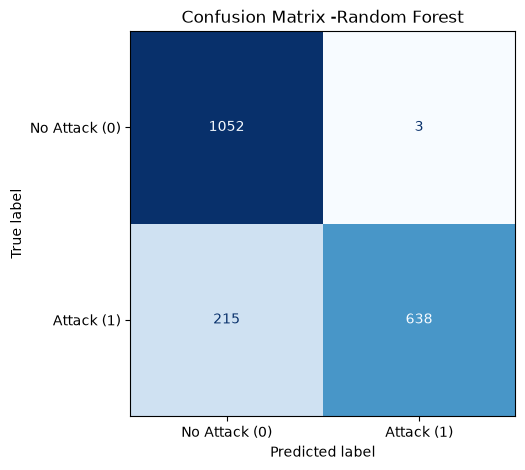

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Attack (0)", "Attack (1)"])

fig, ax = plt.subplots(figsize = (5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix -Random Forest")
plt.show()

In [17]:
cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

TN=1052, FP=3, FN=215, TP=638


In [18]:
precision = tp / (tp + fp)
print(f"Precision: {precision: .4f}")

Precision:  0.9953


In [19]:
recall = tp / (tp + fn)
print(f"Recall: {recall:.4f}")

Recall: 0.7479


In [20]:
from sklearn.metrics import f1_score

f1= f1_score(y_test, predictions)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8541


In [21]:
i=7
original_index = X_test.index[i]
print(df.loc[original_index])


session_id              SID_03661
network_packet_size           427
protocol_type                 TCP
login_attempts                  6
session_duration       521.999875
encryption_used              None
ip_reputation_score      0.442968
failed_logins                   2
browser_type               Chrome
unusual_time_access             0
attack_detected                 1
Name: 3660, dtype: object


In [22]:
print("Your guess: ATTACK ")  
print("Model predicted:", model.predict(X_test.iloc[[i]])[0])
print("Actual label:   ", y_test.iloc[i])

Your guess: ATTACK 
Model predicted: 0
Actual label:    1


# LOGISTIC REGRESSION

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [24]:
log_predictions = log_model.predict(X_test_scaled)

In [25]:
log_accuracy = accuracy_score(y_test, log_predictions)
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print()

print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 0.7296

              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1055
           1       0.72      0.65      0.68       853

    accuracy                           0.73      1908
   macro avg       0.73      0.72      0.72      1908
weighted avg       0.73      0.73      0.73      1908



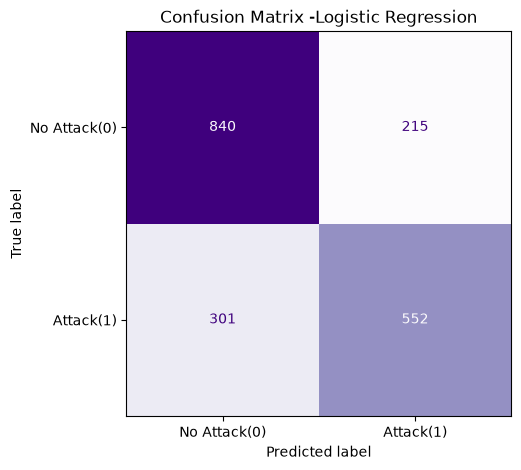

In [26]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, log_predictions),
                              display_labels=["No Attack(0)","Attack(1)"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("Confusion Matrix -Logistic Regression")
plt.show()


In [27]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [accuracy, log_accuracy],
    "F1 Score":[f1_score(y_test, predictions), f1_score(y_test, log_predictions)]
})
comparison

,Model,Accuracy,F1 Score
0,Random Forest,0.885744,0.854083
1,Logistic Regression,0.729560,0.681481


# LINEAR REGRESSION


In [28]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0. , 0.07, 0. ,..., 0. ,-0.01, 0.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['network_packet_size','login_attempts','session_duration',..., 'browser_type_Firefox','browser_type_Safari','browser_type_Unknown']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.3724
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [29]:
lin_predictions = lin_model.predict(X_test)
print(lin_predictions[:10])

[0.23859685 1.04837249 0.33444047 0.20396004 0.26888413 0.24459116
 0.64720386 0.73146497 0.34017659 0.32752563]


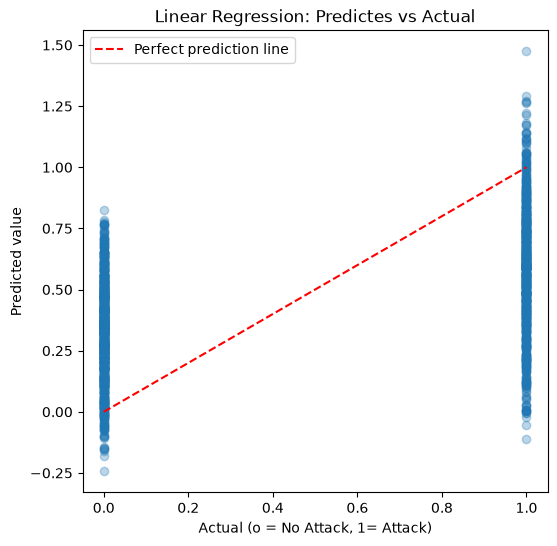

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lin_predictions, alpha=0.3)
plt.plot([0,1],[0,1], color='red', linestyle ="--", label='Perfect prediction line')
plt.xlabel("Actual (o = No Attack, 1= Attack)")
plt.ylabel("Predicted value")
plt.title("Linear Regression: Predictes vs Actual")
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, lin_predictions)
mse = mean_squared_error(y_test, lin_predictions)
r2 = r2_score(y_test, lin_predictions)

print(f"Mean Absolute Error: {mae: .4f}")
print(f"Mean Squared Error: {mse: .4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error:  0.3761
Mean Squared Error:  0.1861
R2 Score: 0.2472


#### Linear Regression underperforms here because it treats a classification problem as if it were continuous regression

# Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [33]:
tree_predictions = tree_model.predict(X_test)

In [34]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, tree_predictions))
print()
print(classification_report(y_test, tree_predictions))

Decision Tree Accuracy: 0.8124

Confusion matrix:
[[873 182]
 [176 677]]

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1055
           1       0.79      0.79      0.79       853

    accuracy                           0.81      1908
   macro avg       0.81      0.81      0.81      1908
weighted avg       0.81      0.81      0.81      1908



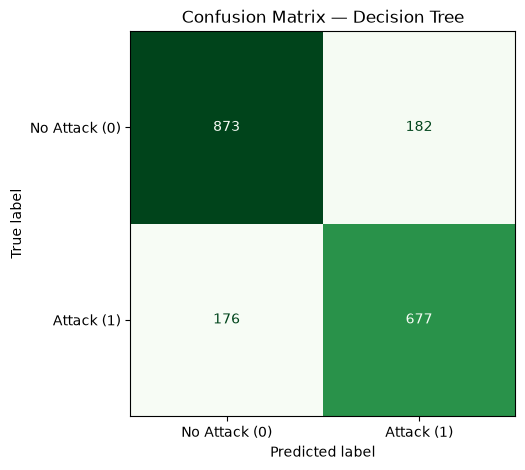

In [35]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, tree_predictions),
                               display_labels=["No Attack (0)", "Attack (1)"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("Confusion Matrix — Decision Tree")
plt.show()

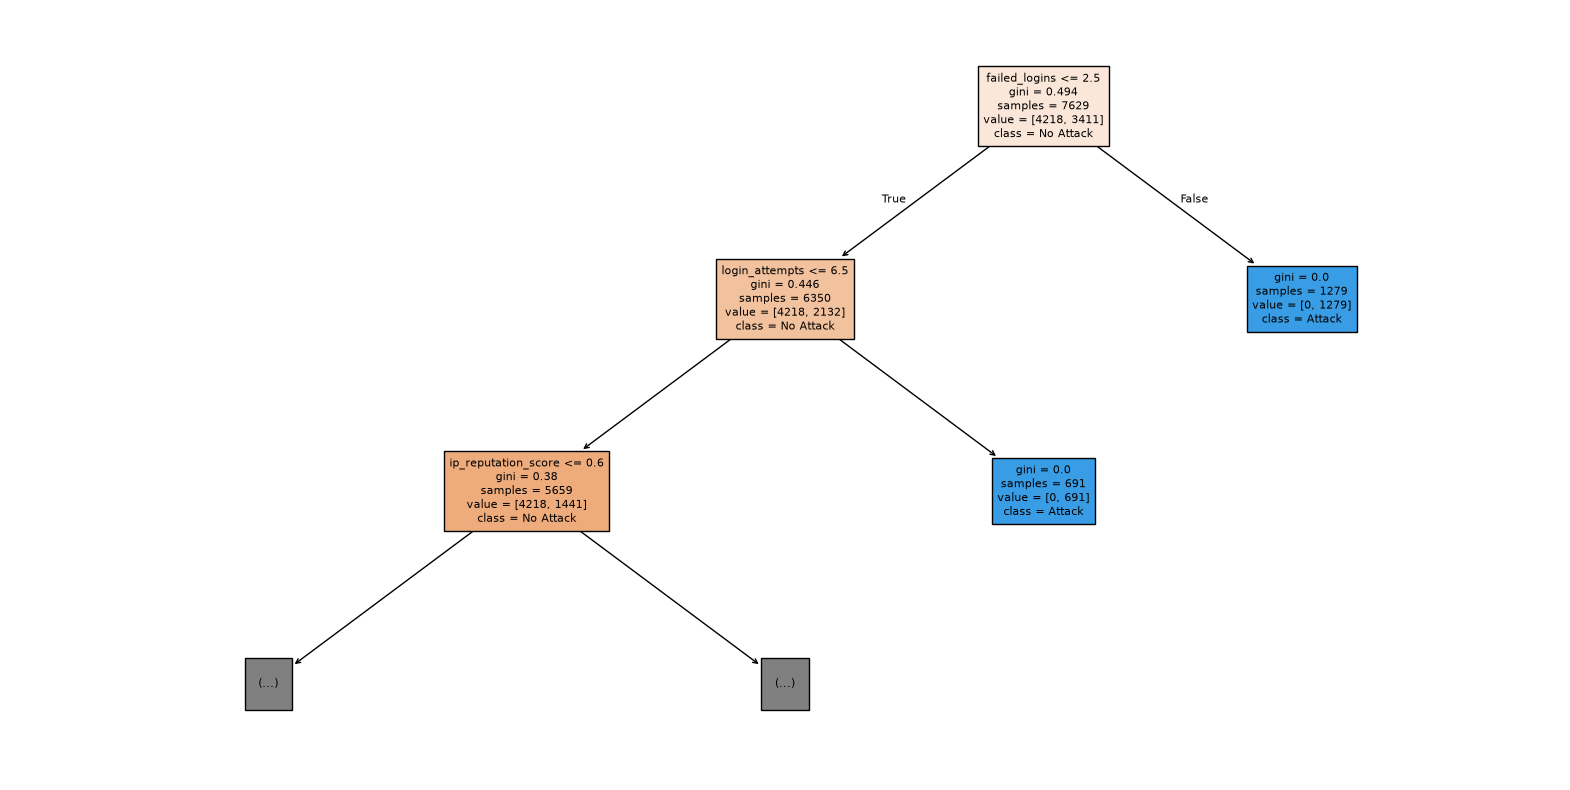

In [37]:
from sklearn.tree import plot_tree

plt.figure(figsize = (20, 10))
plot_tree(tree_model, max_depth = 2, feature_names=X.columns, class_names = ["No Attack", "Attack"], filled=True, fontsize=8)
plt.show()

In [38]:
tree_train_acc = tree_model.score(X_train, y_train)
tree_test_acc = tree_model.score(X_test, y_test)

print(f"Decision Tree - Train Accuracy: {tree_train_acc:.4f}")
print(f"Decision Tree -Test Accuracy: {tree_test_acc:.4f}")
print(f"Gap (train - test): {tree_train_acc - tree_test_acc:.4f}")

Decision Tree - Train Accuracy: 1.0000
Decision Tree -Test Accuracy: 0.8124
Gap (train - test): 0.1876


In [39]:
rf_train_acc = model.score(X_train, y_train)
rf_test_acc = model.score(X_test, y_test)

print(f"Random Forest — Train Accuracy: {rf_train_acc:.4f}")
print(f"Random Forest — Test Accuracy:  {rf_test_acc:.4f}")
print(f"Gap (train - test): {rf_train_acc - rf_test_acc:.4f}")

Random Forest — Train Accuracy: 1.0000
Random Forest — Test Accuracy:  0.8857
Gap (train - test): 0.1143


# XGBoost


In [ ]:
!pip install xgboost

In [40]:
#Train
from xgboost import XGBClassifier
xgb_model = XGBClassifier (n_estimator = 200, random_state = 42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

C:\Users\Uswa Khalil\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:23:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
xgb_predictions = xgb_model.predict(X_test)

print("Predicted:" , xgb_predictions[:20])
print("Actual: ", y_test.values[:20])

Predicted: [1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0]
Actual:  [1 1 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0]


In [42]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, xgb_predictions))
print()
print(classification_report(y_test, xgb_predictions))


XGBoost Accuracy: 0.8784

Confusion matrix:
[[1032   23]
 [ 209  644]]

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      1055
           1       0.97      0.75      0.85       853

    accuracy                           0.88      1908
   macro avg       0.90      0.87      0.87      1908
weighted avg       0.89      0.88      0.88      1908



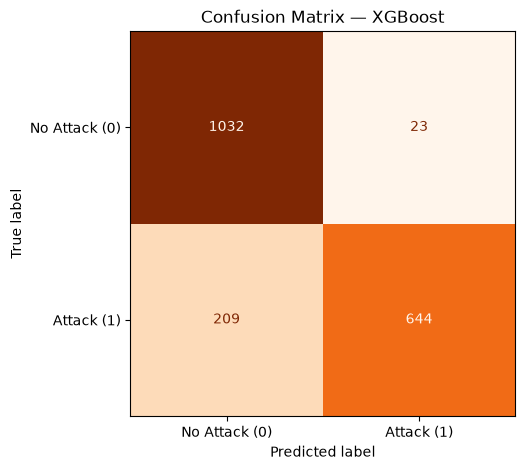

In [43]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, xgb_predictions),
                               display_labels=["No Attack (0)", "Attack (1)"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
plt.title("Confusion Matrix — XGBoost")
plt.show()

In [44]:
xgb_train_acc = xgb_model.score(X_train, y_train)
xgb_test_acc = xgb_model.score(X_test, y_test)

print(f"XGBoost — Train Accuracy: {xgb_train_acc:.4f}")
print(f"XGBoost — Test Accuracy:  {xgb_test_acc:.4f}")
print(f"Gap (train - test): {xgb_train_acc - xgb_test_acc:.4f}")

XGBoost — Train Accuracy: 0.9392
XGBoost — Test Accuracy:  0.8784
Gap (train - test): 0.0608


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [46]:
from sklearn.metrics import accuracy_score, f1_score

lin_predictions_rounded = np.clip(np.round(lin_predictions), 0, 1).astype(int)

models_results = {
    "Random Forest": predictions,
    "Logistic Regression": log_predictions,
    "Decision Tree":  tree_predictions,
    "XGBoost": xgb_predictions,
    "Linear Regression (rounded)": lin_predictions_rounded
}

comparison_rows =[]
for model_names, preds in models_results.items():
    comparison_rows.append({
        "Model":model_names,
        "Accuracy" :accuracy_score(y_test, preds),
        "Precision":precision_score(y_test,preds),
        "Recall":recall_score(y_test, preds),
        "F1 Sciore":f1_score(y_test, preds)
})

final_comparison = pd.DataFrame(comparison_rows)
final_comparison = final_comparison.sort_values("Accuracy", ascending=False).reset_index(drop=True)
final_comparison

,Model,Accuracy,Precision,Recall,F1 Sciore
0,Random Forest,0.885744,0.995320,0.747948,0.854083
1,XGBoost,0.878407,0.965517,0.754982,0.847368
2,Decision Tree,0.812369,0.788126,0.793669,0.790888
3,Linear Regression (rounded),0.730084,0.725333,0.637749,0.678727
4,Logistic Regression,0.729560,0.719687,0.647128,0.681481


## Saving the best performing model - RANDOM FOREST

In [47]:
import joblib
joblib.dump(model, "Random_forest_intrusion_model.pkl")

['Random_forest_intrusion_model.pkl']